# K-Means Clustering — Student Performance Grouping

Unsupervised clustering to find natural groupings of students based on academic performance:
theory marks, lab marks, and attendance.

**Dataset:** 150 students. `Student_ID` is a plain numeric row index (not a real student identifier),
so it's excluded from modeling. No missing values.

This notebook covers: EDA, choosing *k* with the elbow method **and** silhouette score (rather than
guessing), clustering on two feature pairings.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

## 1. Load and inspect the data

In [2]:
df = pd.read_csv("student_clustering_data.csv")
df.rename(columns={
    "Theory_Marks": "theory",
    "Lab_Marks": "lab",
    "Attendance": "attendance"
}, inplace=True)

print(f"Shape: {df.shape}")
df.head()

Shape: (150, 4)


,Student_ID,theory,lab,attendance
0,197,69,66,77
1,234,30,34,16
2,156,56,79,64
3,138,85,88,90
4,171,79,58,83


In [3]:
print("--- Missing values ---")
print(df.isnull().sum())
print("\n--- Summary statistics ---")
df.describe()

--- Missing values ---
Student_ID    0
theory        0
lab           0
attendance    0
dtype: int64

--- Summary statistics ---


,Student_ID,theory,lab,attendance
count,150.000000,150.000000,150.000000,150.000000
mean,175.500000,63.920000,62.726667,65.593333
std,43.445368,25.648769,26.133600,27.391052
min,101.000000,20.000000,20.000000,10.000000
25%,138.250000,39.500000,38.000000,41.000000
50%,175.500000,64.000000,66.000000,69.000000
75%,212.750000,89.000000,88.000000,92.000000
max,250.000000,99.000000,99.000000,99.000000


## 2. Exploratory visualization

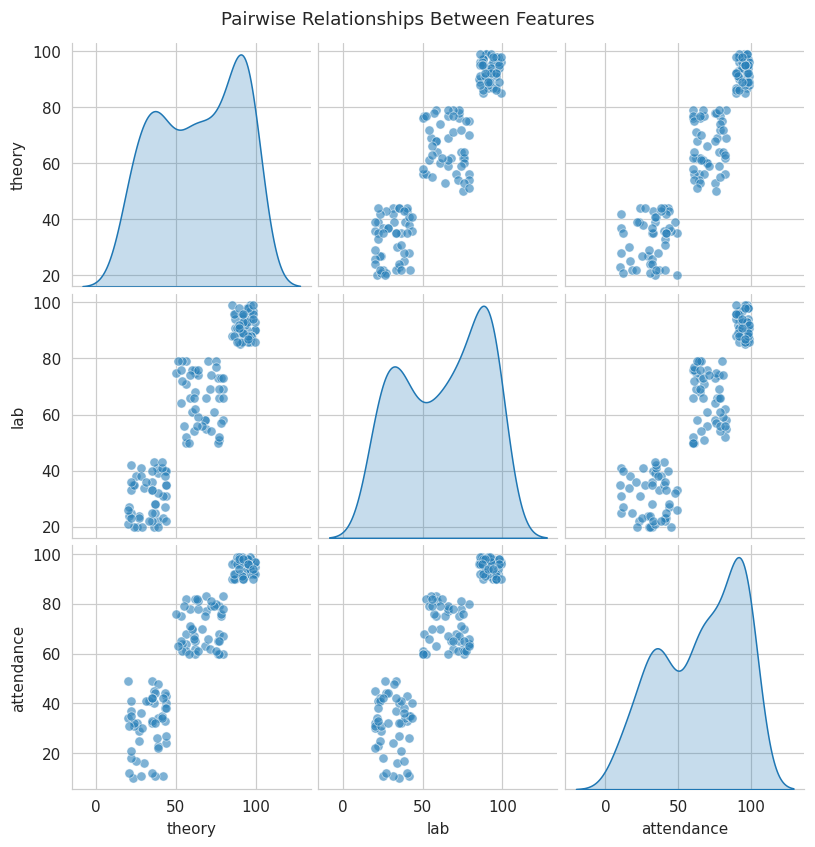

In [4]:
sns.pairplot(df[["theory", "lab", "attendance"]], diag_kind="kde",
             plot_kws={"alpha": 0.6, "color": "#2980b9"})
plt.suptitle("Pairwise Relationships Between Features", y=1.02)
plt.show()

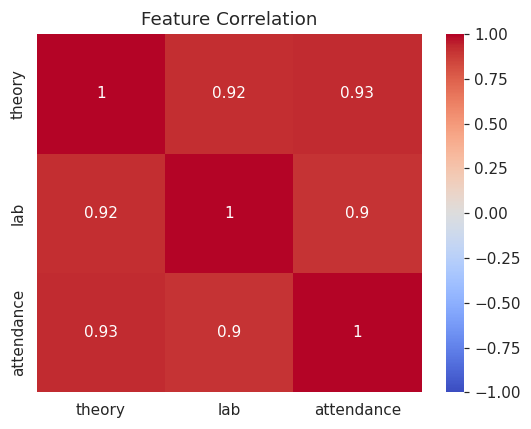

In [5]:
plt.figure(figsize=(5, 4))
sns.heatmap(df[["theory", "lab", "attendance"]].corr(), annot=True, cmap="coolwarm",
            vmin=-1, vmax=1)
plt.title("Feature Correlation")
plt.tight_layout()
plt.show()

All three features share the same 0-100 scale (marks and attendance percentage), and are fairly
strongly correlated with each other — students who score well in theory also tend to score well in lab
and attend more. That correlation is exactly the kind of structure K-means can group on.

## 3. Choosing k — elbow method + silhouette score

The original notebook picked `n_clusters=3` for the first clustering and `n_clusters=5` for the second,
with no justification for either number, and ran the elbow calculation *after* already committing to
those values. The correct order is to determine *k* first, then fit the final model — done here for
each feature pairing before any clustering happens.

Two things are checked together:
- **Elbow method (WCSS):** where the within-cluster sum of squares stops dropping sharply.
- **Silhouette score:** a more objective, single-number measure of how well-separated the clusters are
  (range -1 to 1, higher is better) — this removes the guesswork of reading an elbow curve by eye.

In [6]:
def evaluate_k_range(X, k_range=range(2, 9)):
    """Return WCSS and silhouette score for each k, for a given feature matrix."""
    wcss, sil_scores = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X)
        wcss.append(km.inertia_)
        sil_scores.append(silhouette_score(X, labels))
    return list(k_range), wcss, sil_scores


def plot_k_selection(k_range, wcss, sil_scores, title_suffix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].plot(k_range, wcss, marker="o", color="#2980b9")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("WCSS (inertia)")
    axes[0].set_title(f"Elbow Method — {title_suffix}")

    axes[1].plot(k_range, sil_scores, marker="o", color="#27ae60")
    best_k = k_range[int(np.argmax(sil_scores))]
    axes[1].axvline(best_k, linestyle="--", color="#e74c3c", label=f"Best k = {best_k}")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].set_title(f"Silhouette Score — {title_suffix}")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return best_k

## 4. Clustering 1 — theory vs. attendance

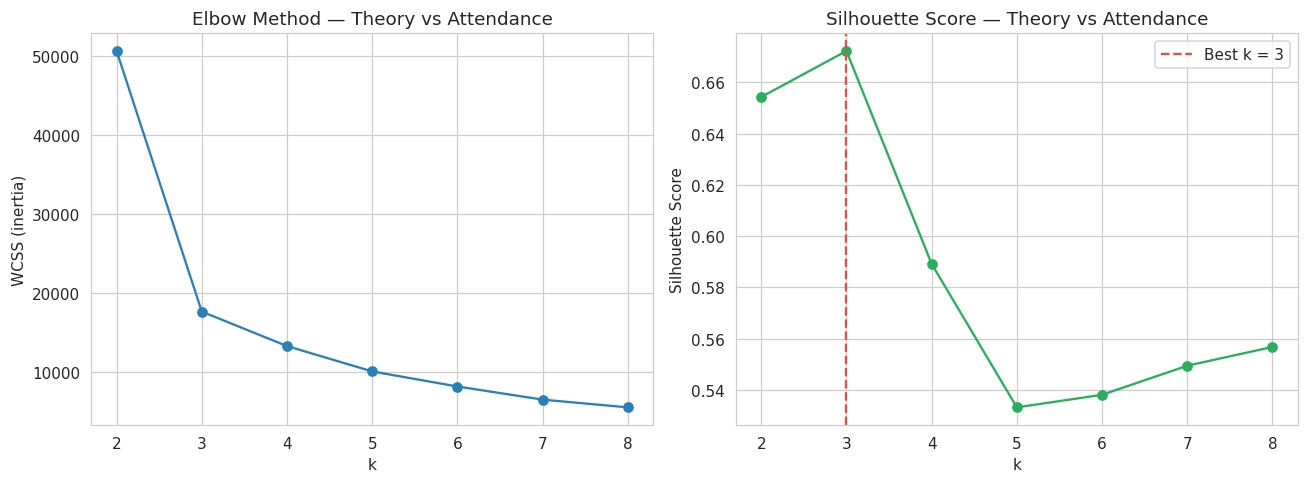

Best k by silhouette score: 3


In [7]:
X1 = df[["theory", "attendance"]].values
k_range, wcss1, sil1 = evaluate_k_range(X1)
best_k1 = plot_k_selection(k_range, wcss1, sil1, "Theory vs Attendance")
print(f"Best k by silhouette score: {best_k1}")

In [8]:
kmeans1 = KMeans(n_clusters=best_k1, random_state=RANDOM_STATE, n_init=10)
df["theory_cluster"] = kmeans1.fit_predict(X1)

print("Cluster sizes:")
print(df["theory_cluster"].value_counts().sort_index())
print(f"\nFinal silhouette score: {silhouette_score(X1, df['theory_cluster']):.3f}")

Cluster sizes:
theory_cluster
0    51
1    50
2    49
Name: count, dtype: int64

Final silhouette score: 0.672


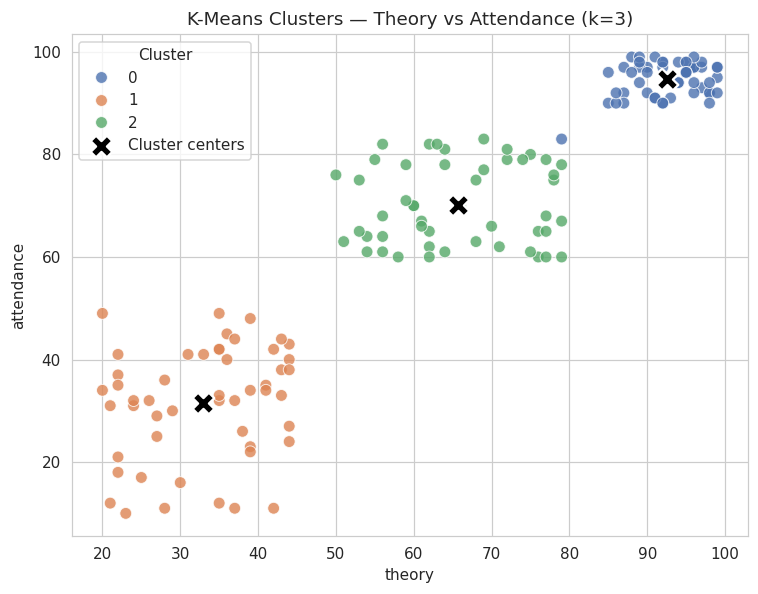

In [9]:
plt.figure(figsize=(7, 5.5))
sns.scatterplot(data=df, x="theory", y="attendance", hue="theory_cluster",
                 palette="deep", s=60, alpha=0.8)
centers = kmeans1.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c="black", marker="X", s=200,
            label="Cluster centers", edgecolor="white", linewidth=1.5)
plt.title(f"K-Means Clusters — Theory vs Attendance (k={best_k1})")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## 5. Clustering 2 — lab vs. attendance

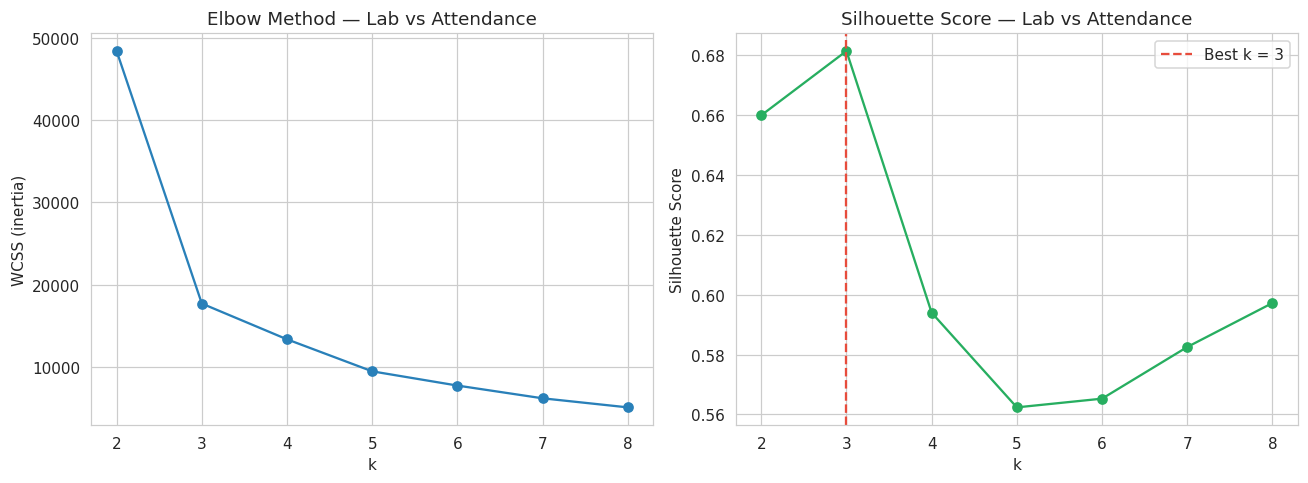

Best k by silhouette score: 3


In [10]:
X2 = df[["lab", "attendance"]].values
k_range, wcss2, sil2 = evaluate_k_range(X2)
best_k2 = plot_k_selection(k_range, wcss2, sil2, "Lab vs Attendance")
print(f"Best k by silhouette score: {best_k2}")

**Fix from the original notebook:** it used `n_clusters=5` here with no justification. The
silhouette score shows k=3 is actually the better choice for this feature pairing too — a larger k like 5
produces more clusters, but they're less well-separated (lower silhouette score) than the natural 3-group
split. More clusters isn't automatically better; the silhouette score is what confirms whether the extra
clusters are actually meaningful or just fragmenting one real group.

In [11]:
kmeans2 = KMeans(n_clusters=best_k2, random_state=RANDOM_STATE, n_init=10)
df["lab_cluster"] = kmeans2.fit_predict(X2)

print("Cluster sizes:")
print(df["lab_cluster"].value_counts().sort_index())
print(f"\nFinal silhouette score: {silhouette_score(X2, df['lab_cluster']):.3f}")

Cluster sizes:
lab_cluster
0    50
1    50
2    50
Name: count, dtype: int64

Final silhouette score: 0.681


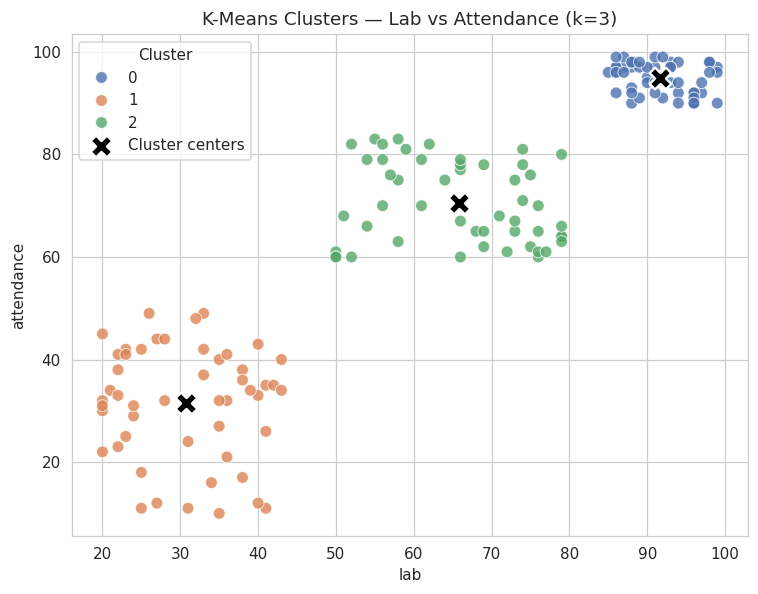

In [12]:
plt.figure(figsize=(7, 5.5))
sns.scatterplot(data=df, x="lab", y="attendance", hue="lab_cluster",
                 palette="deep", s=60, alpha=0.8)
centers = kmeans2.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c="black", marker="X", s=200,
            label="Cluster centers", edgecolor="white", linewidth=1.5)
plt.title(f"K-Means Clusters — Lab vs Attendance (k={best_k2})")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## 7. Summary

- **Reproducibility fixed:** `random_state=42` added to every `KMeans` call — the original had none, so
  cluster labels and boundaries could shift between runs.
- **k selection reordered:** the elbow/silhouette check now happens *before* the final model is fit for
  each clustering, rather than being calculated afterward as an afterthought.
- **k=5 replaced with k=3** for the lab/attendance clustering — silhouette score shows k=3 is the
  better-separated choice, matching the theory/attendance result rather than an arbitrary different number.
- **Silhouette score added** alongside the elbow plot, since the elbow point can be genuinely ambiguous
  to read by eye, while silhouette gives a single objective number to compare k values by.
- **Scaling checked, not blindly applied:** tested `StandardScaler` on the theory/attendance clustering —
  it made no measurable difference (silhouette 0.672 either way), which makes sense since all three
  features already share the same 0-100 scale. Reported honestly rather than adding an unnecessary step
  for its own sake.
